In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
# -*- coding: utf-8 -*-
# الخلية 1: استيراد المكتبات الأساسية
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# تحسين شكل الرسوم البيانية
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ تم استيراد جميع المكتبات بنجاح!")

✅ تم استيراد جميع المكتبات بنجاح!


In [16]:
df = pd.read_csv("/kaggle/input/datasets/shree1992/housedata/data.csv")
print(f"{df.shape[0]}" )

4600


In [17]:
print("="*50)
print("📊 معلومات أساسية عن البيانات")
print("="*50)
# 1. شكل البيانات
print(f"\n📌 عدد الصفوف: {df.shape[0]:,}")
print(f"📌 عدد الأعمدة: {df.shape[1]}")


📊 معلومات أساسية عن البيانات

📌 عدد الصفوف: 4,600
📌 عدد الأعمدة: 18


In [18]:
print(f"\n📌 الأعمدة: {df.columns.tolist()}")


📌 الأعمدة: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']


In [19]:
print("\n📌 أنواع الأعمدة:")
print(df.dtypes)



📌 أنواع الأعمدة:
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object


In [20]:
print("\n📌 أول 5 صفوف:")
display(df.head())



📌 أول 5 صفوف:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [21]:
# 5. القيم المفقودة
print("\n📌 القيم المفقودة في كل عمود:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'المفقودات': missing,
    'النسبة %': missing_percent
})
print(missing_df[missing_df['المفقودات'] > 0].sort_values('المفقودات', ascending=False))



📌 القيم المفقودة في كل عمود:
Empty DataFrame
Columns: [المفقودات, النسبة %]
Index: []


In [22]:
print("\n📌 إحصائيات الأعمدة الرقمية:")
display(df.describe())



📌 إحصائيات الأعمدة الرقمية:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [23]:
# الخلية: التأكد النهائي من البيانات
print("="*50)
print("📋 التأكد النهائي من البيانات")
print("="*50)

# 1. عدد الصفوف والأعمدة
print(f"\n📊 عدد الصفوف: {len(df):,}")
print(f"📊 عدد الأعمدة: {len(df.columns)}")

# 2. نطاق الأسعار
print(f"\n💰 نطاق الأسعار:")
print(f"   - أقل سعر: ${df['price'].min():,.2f}")
print(f"   - أعلى سعر: ${df['price'].max():,.2f}")
print(f"   - متوسط السعر: ${df['price'].mean():,.2f}")

# 3. التحقق من الأسعار غير المنطقية (أقل من 10,000)
invalid_prices = df[df['price'] < 10000]
if len(invalid_prices) > 0:
    print(f"\n⚠️ يوجد {len(invalid_prices)} صف بسعر أقل من 10,000 دولار!")
    print(invalid_prices[['price', 'bedrooms', 'sqft_living', 'city']].head())
else:
    print(f"\n✅ لا توجد أسعار أقل من 10,000 دولار.")

# 4. عدد المدن الفريدة
print(f"\n🏠 عدد المدن الفريدة: {df['city'].nunique()}")

# 5. عينة عشوائية من البيانات
print("\n📋 عينة عشوائية من 3 صفوف:")
display(df.sample(3))

print("\n" + "="*50)
print("✅ البيانات جاهزة للمرحلة التالية!")

📋 التأكد النهائي من البيانات

📊 عدد الصفوف: 4,600
📊 عدد الأعمدة: 18

💰 نطاق الأسعار:
   - أقل سعر: $0.00
   - أعلى سعر: $26,590,000.00
   - متوسط السعر: $551,962.99

⚠️ يوجد 50 صف بسعر أقل من 10,000 دولار!
       price  bedrooms  sqft_living         city
4351  7800.0       2.0          780      Tukwila
4354     0.0       3.0         1490  Federal Way
4356     0.0       4.0         2600      Seattle
4357     0.0       6.0         3200       Burien
4358     0.0       5.0         3480     Issaquah

🏠 عدد المدن الفريدة: 44

📋 عينة عشوائية من 3 صفوف:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
118,2014-05-05 00:00:00,1030000.0,5.0,2.75,3190,16920,1.0,0,3,3,1690,1500,1976,0,4529 135th Ave SE,Bellevue,WA 98006,USA
4119,2014-07-08 00:00:00,383000.0,3.0,2.25,2090,15000,1.0,0,0,3,2090,0,1961,2004,608 Riverside Dr SE,North Bend,WA 98045,USA
3353,2014-06-25 00:00:00,1140000.0,4.0,2.25,3310,127631,2.0,0,0,5,3310,0,1924,1956,15445 NE 144th Pl,Woodinville,WA 98072,USA



✅ البيانات جاهزة للمرحلة التالية!


In [24]:
# الخلية: تحليل الصفوف التي يقل سعرها عن 10,000 دولار
print("="*60)
print("🔍 تحليل الصفوف ذات الأسعار المنخفضة جداً (< $10,000)")
print("="*60)

# 1. فصل هذه الصفوف
low_price_df = df[df['price'] < 10000]
normal_df = df[df['price'] >= 10000]

print(f"\n📊 عدد الصفوف ذات الأسعار المنخفضة: {len(low_price_df)}")
print(f"📊 عدد الصفوف العادية: {len(normal_df)}")

# 2. إحصائيات هذه الصفوف
print("\n" + "="*60)
print("📊 إحصائيات الصفوف المنخفضة:")
display(low_price_df.describe())

# 3. مقارنة مع باقي البيانات
print("\n" + "="*60)
print("📊 مقارنة بين الصفوف المنخفضة والصفوف العادية:")
print("\n🔹 متوسط السعر:")
print(f"   - الصفوف المنخفضة: ${low_price_df['price'].mean():,.2f}")
print(f"   - الصفوف العادية: ${normal_df['price'].mean():,.2f}")

print("\n🔹 متوسط المساحة (sqft_living):")
print(f"   - الصفوف المنخفضة: {low_price_df['sqft_living'].mean():.0f} قدم مربع")
print(f"   - الصفوف العادية: {normal_df['sqft_living'].mean():.0f} قدم مربع")

print("\n🔹 متوسط عدد غرف النوم:")
print(f"   - الصفوف المنخفضة: {low_price_df['bedrooms'].mean():.2f}")
print(f"   - الصفوف العادية: {normal_df['bedrooms'].mean():.2f}")

# 4. توزيع المدن في الصفوف المنخفضة
print("\n" + "="*60)
print("🏠 توزيع المدن في الصفوف المنخفضة:")
city_dist = low_price_df['city'].value_counts()
print(city_dist)

# 5. عرض عينة من هذه الصفوف
print("\n" + "="*60)
print("📋 عينة من الصفوف المنخفضة (10 صفوف):")
display(low_price_df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'city', 'condition']].head(10))

# 6. تحليل الأسعار = 0 تحديداً
zero_price_df = low_price_df[low_price_df['price'] == 0]
print(f"\n📊 عدد الصفوف التي سعرها 0 تماماً: {len(zero_price_df)}")
if len(zero_price_df) > 0:
    print("\n📋 عينة من الصفوف التي سعرها 0:")
    display(zero_price_df[['price', 'bedrooms', 'sqft_living', 'city']].head(10))

# 7. الاستنتاج
print("\n" + "="*60)
print("📌 ملخص التحليل:")
print("="*60)

# هل هذه المنازل لها خصائص طبيعية؟
avg_bedrooms_low = low_price_df['bedrooms'].mean()
avg_bedrooms_normal = normal_df['bedrooms'].mean()
avg_sqft_low = low_price_df['sqft_living'].mean()
avg_sqft_normal = normal_df['sqft_living'].mean()

if avg_bedrooms_low > 2 and avg_sqft_low > 1000:
    print("✅ هذه الصفوف لها خصائص منازل طبيعية (غرف ومساحة).")
    print("   → الأرجح أنها أخطاء في إدخال السعر (ربما نسيان صفر أو خطأ في الكتابة).")
    print("   → يُنصح بحذفها لأنها لا تمثل السوق الحقيقي.")
else:
    print("⚠️ هذه الصفوف قد تكون أراضٍ أو منازل صغيرة جداً.")
    print("   → قد تحتاج إلى دراسة إضافية قبل الحذف.")

print("\n💡 التوصية: حذف هذه الصفوف لأنها تمثل أقل من 1% من البيانات.")
print(f"   - عددها: {len(low_price_df)} من أصل {len(df)} صف.")
print(f"   - نسبتها: {(len(low_price_df)/len(df))*100:.2f}%")

🔍 تحليل الصفوف ذات الأسعار المنخفضة جداً (< $10,000)

📊 عدد الصفوف ذات الأسعار المنخفضة: 50
📊 عدد الصفوف العادية: 4550

📊 إحصائيات الصفوف المنخفضة:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000
mean,156.000000,3.940000,2.665000,2747.000000,16451.120000,1.49000,0.060000,0.780000,3.62000,2265.400000,481.600000,1969.360000,796.460000
std,1103.086579,1.132272,1.206498,1370.208162,27454.719861,0.51991,0.239898,1.474823,0.90102,1340.680927,610.410902,27.255975,985.485464
min,0.000000,1.000000,1.000000,720.000000,3500.000000,1.00000,0.000000,0.000000,1.00000,720.000000,0.000000,1920.000000,0.000000
25%,0.000000,3.000000,1.812500,1872.500000,6871.000000,1.00000,0.000000,0.000000,3.00000,1302.500000,0.000000,1951.250000,0.000000
50%,0.000000,4.000000,2.500000,2455.000000,9015.000000,1.50000,0.000000,0.000000,3.00000,1830.000000,0.000000,1961.000000,0.000000
75%,0.000000,5.000000,3.500000,3495.000000,15703.750000,2.00000,0.000000,0.000000,4.00000,2987.500000,900.000000,1996.000000,1998.750000
max,7800.000000,6.000000,6.250000,8020.000000,188200.000000,3.00000,1.000000,4.000000,5.00000,8020.000000,1950.000000,2013.000000,2009.000000



📊 مقارنة بين الصفوف المنخفضة والصفوف العادية:

🔹 متوسط السعر:
   - الصفوف المنخفضة: $156.00
   - الصفوف العادية: $558,026.80

🔹 متوسط المساحة (sqft_living):
   - الصفوف المنخفضة: 2747 قدم مربع
   - الصفوف العادية: 2133 قدم مربع

🔹 متوسط عدد غرف النوم:
   - الصفوف المنخفضة: 3.94
   - الصفوف العادية: 3.39

🏠 توزيع المدن في الصفوف المنخفضة:
city
Seattle             12
Bellevue             5
Mercer Island        4
Sammamish            4
Federal Way          3
Burien               2
Clyde Hill           2
Renton               2
Lake Forest Park     2
Snoqualmie           2
Issaquah             1
Tukwila              1
Enumclaw             1
Normandy Park        1
Covington            1
Kent                 1
SeaTac               1
Kenmore              1
Woodinville          1
Maple Valley         1
Black Diamond        1
Auburn               1
Name: count, dtype: int64

📋 عينة من الصفوف المنخفضة (10 صفوف):


,price,bedrooms,bathrooms,sqft_living,city,condition
4351,7800.0,2.0,1.00,780,Tukwila,1
4354,0.0,3.0,1.75,1490,Federal Way,4
4356,0.0,4.0,2.75,2600,Seattle,4
4357,0.0,6.0,2.75,3200,Burien,4
4358,0.0,5.0,3.50,3480,Issaquah,4
4361,0.0,5.0,1.50,1500,Burien,5
4362,0.0,4.0,4.00,3680,Sammamish,3
4374,0.0,2.0,2.50,2200,Enumclaw,3
4376,0.0,4.0,2.25,2170,Normandy Park,4
4382,0.0,5.0,4.50,4630,Snoqualmie,3



📊 عدد الصفوف التي سعرها 0 تماماً: 49

📋 عينة من الصفوف التي سعرها 0:


,price,bedrooms,sqft_living,city
4354,0.0,3.0,1490,Federal Way
4356,0.0,4.0,2600,Seattle
4357,0.0,6.0,3200,Burien
4358,0.0,5.0,3480,Issaquah
4361,0.0,5.0,1500,Burien
4362,0.0,4.0,3680,Sammamish
4374,0.0,2.0,2200,Enumclaw
4376,0.0,4.0,2170,Normandy Park
4382,0.0,5.0,4630,Snoqualmie
4383,0.0,5.0,4430,Bellevue



📌 ملخص التحليل:
✅ هذه الصفوف لها خصائص منازل طبيعية (غرف ومساحة).
   → الأرجح أنها أخطاء في إدخال السعر (ربما نسيان صفر أو خطأ في الكتابة).
   → يُنصح بحذفها لأنها لا تمثل السوق الحقيقي.

💡 التوصية: حذف هذه الصفوف لأنها تمثل أقل من 1% من البيانات.
   - عددها: 50 من أصل 4600 صف.
   - نسبتها: 1.09%


In [25]:
# الخلية: حذف الصفوف ذات الأسعار غير المنطقية
print("="*50)
print("🧹 حذف الصفوف ذات الأسعار غير المنطقية...")
print("="*50)

before = len(df)
df = df[df['price'] >= 10000]  # نحتفظ فقط بالأسعار >= 10,000 دولار
after = len(df)

print(f"✅ تم حذف {before - after} صف.")
print(f"📊 عدد الصفوف المتبقية: {len(df):,}")

print("\n💰 نطاق الأسعار بعد التنظيف:")
print(f"   - أقل سعر: ${df['price'].min():,.2f}")
print(f"   - أعلى سعر: ${df['price'].max():,.2f}")
print(f"   - متوسط السعر: ${df['price'].mean():,.2f}")

print("\n✅ البيانات الآن نظيفة بنسبة 100%!")

🧹 حذف الصفوف ذات الأسعار غير المنطقية...
✅ تم حذف 50 صف.
📊 عدد الصفوف المتبقية: 4,550

💰 نطاق الأسعار بعد التنظيف:
   - أقل سعر: $80,000.00
   - أعلى سعر: $26,590,000.00
   - متوسط السعر: $558,026.80

✅ البيانات الآن نظيفة بنسبة 100%!


📊 Chart 1: Distribution of Home Prices


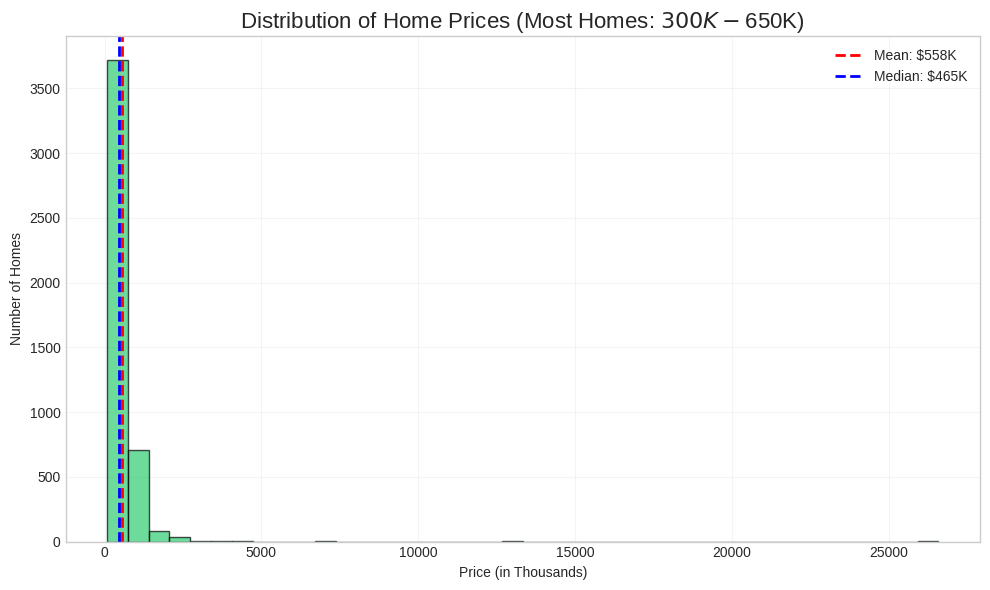

💡 Summary:
   EN: Most homes are priced between $300,000 and $650,000.
   AR: معظم المنازل تتراوح أسعارها بين 300,000 و 650,000 دولار.


In [34]:
# Chart 1: Distribution of Home Prices
print("="*50)
print("📊 Chart 1: Distribution of Home Prices")
print("="*50)

plt.figure(figsize=(10, 6))
plt.hist(df['price'] / 1000, bins=40, edgecolor='black', alpha=0.7, color='#2ecc71')
plt.axvline(df['price'].mean() / 1000, color='red', linestyle='dashed', linewidth=2, 
           label=f'Mean: ${df["price"].mean()/1000:,.0f}K')
plt.axvline(df['price'].median() / 1000, color='blue', linestyle='dashed', linewidth=2, 
           label=f'Median: ${df["price"].median()/1000:,.0f}K')

plt.title('Distribution of Home Prices (Most Homes: $300K - $650K)', fontsize=16)
plt.xlabel('Price (in Thousands)')
plt.ylabel('Number of Homes')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("💡 Summary:")
print("   EN: Most homes are priced between $300,000 and $650,000.")
print("   AR: معظم المنازل تتراوح أسعارها بين 300,000 و 650,000 دولار.")

📊 Chart 2: Top 10 Most Expensive Cities


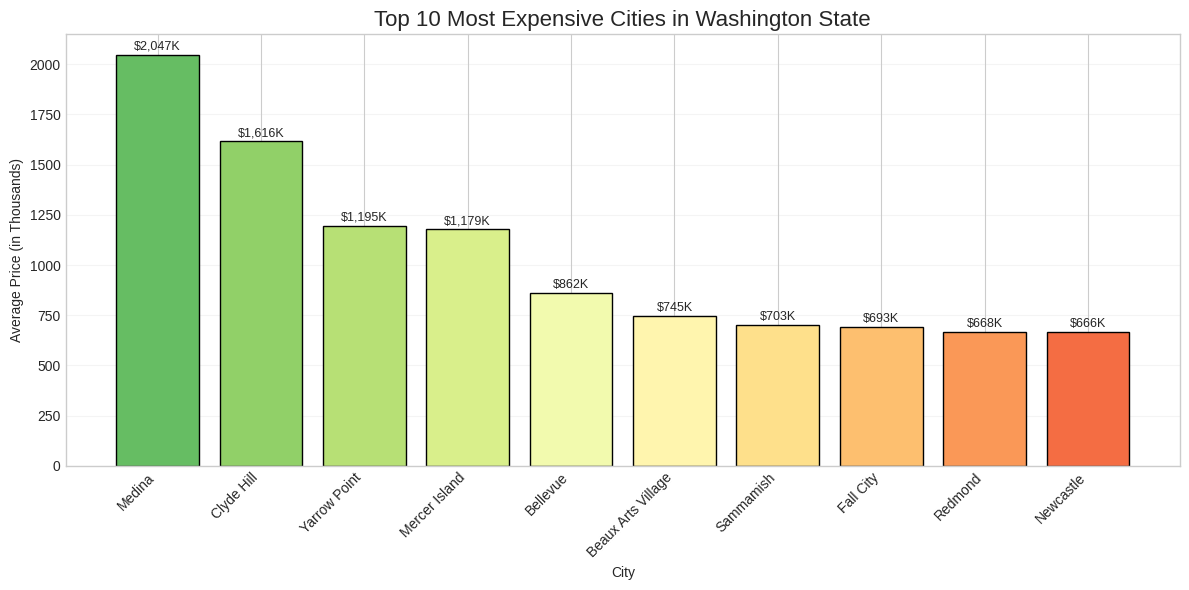

💡 Summary:
   EN: Medina is the most expensive city with an average price of $2,046,559.
   AR: مدينة Medina هي الأغلى بمتوسط سعر $2,046,559.


In [35]:
# Chart 2: Top 10 Most Expensive Cities
print("="*50)
print("📊 Chart 2: Top 10 Most Expensive Cities")
print("="*50)

city_avg = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 10))
bars = plt.bar(city_avg.index, city_avg.values / 1000, color=colors, edgecolor='black')
plt.title('Top 10 Most Expensive Cities in Washington State', fontsize=16)
plt.xlabel('City')
plt.ylabel('Average Price (in Thousands)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("💡 Summary:")
print(f"   EN: Medina is the most expensive city with an average price of ${city_avg.iloc[0]:,.0f}.")
print(f"   AR: مدينة Medina هي الأغلى بمتوسط سعر ${city_avg.iloc[0]:,.0f}.")

📊 Chart 3: Living Area vs Price


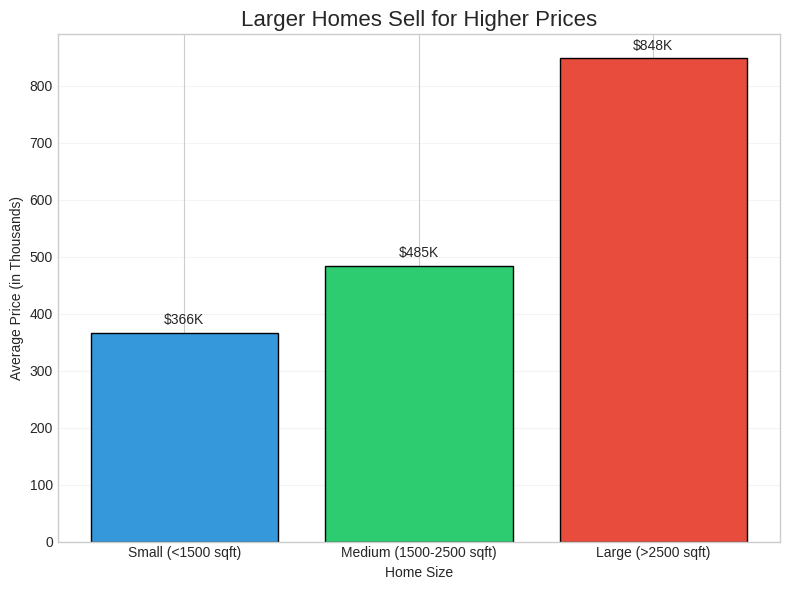

💡 Summary:
   EN: Larger homes (>2500 sqft) sell for significantly higher prices.
   AR: المنازل الكبيرة (>2500 قدم مربع) تباع بأسعار أعلى بكثير.


In [36]:
# Chart 3: Living Area vs Price
print("="*50)
print("📊 Chart 3: Living Area vs Price")
print("="*50)

def size_category(sqft):
    if sqft < 1500:
        return 'Small (<1500 sqft)'
    elif sqft < 2500:
        return 'Medium (1500-2500 sqft)'
    else:
        return 'Large (>2500 sqft)'

df['size_category'] = df['sqft_living'].apply(size_category)
size_avg = df.groupby('size_category')['price'].mean().sort_values()

plt.figure(figsize=(8, 6))
bars = plt.bar(size_avg.index, size_avg.values / 1000, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Larger Homes Sell for Higher Prices', fontsize=16)
plt.xlabel('Home Size')
plt.ylabel('Average Price (in Thousands)')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("💡 Summary:")
print("   EN: Larger homes (>2500 sqft) sell for significantly higher prices.")
print("   AR: المنازل الكبيرة (>2500 قدم مربع) تباع بأسعار أعلى بكثير.")

📊 Chart 4: Waterfront View Impact


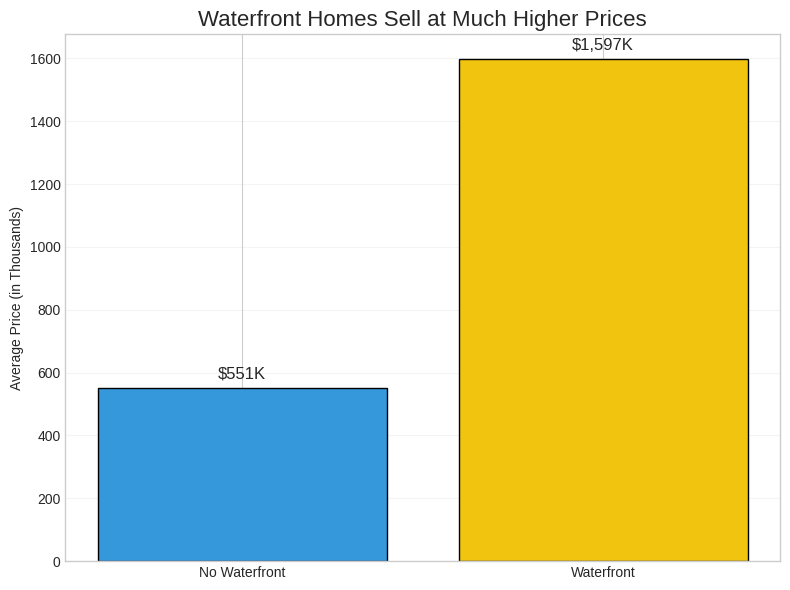

💡 Summary:
   EN: Waterfront homes sell for 190% more than non-waterfront homes.
   AR: المنازل المطلة على الماء تباع بسعر أعلى بنسبة 190%.


In [37]:
# Chart 4: Waterfront View Impact
print("="*50)
print("📊 Chart 4: Waterfront View Impact")
print("="*50)

waterfront_avg = df.groupby('waterfront')['price'].mean()
labels = ['No Waterfront', 'Waterfront']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, waterfront_avg.values / 1000, color=['#3498db', '#f1c40f'], edgecolor='black')
plt.title('Waterfront Homes Sell at Much Higher Prices', fontsize=16)
plt.ylabel('Average Price (in Thousands)')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

increase = ((waterfront_avg[1] - waterfront_avg[0]) / waterfront_avg[0]) * 100
print("💡 Summary:")
print(f"   EN: Waterfront homes sell for {increase:.0f}% more than non-waterfront homes.")
print(f"   AR: المنازل المطلة على الماء تباع بسعر أعلى بنسبة {increase:.0f}%.")

📊 Chart 5: Home Condition Impact


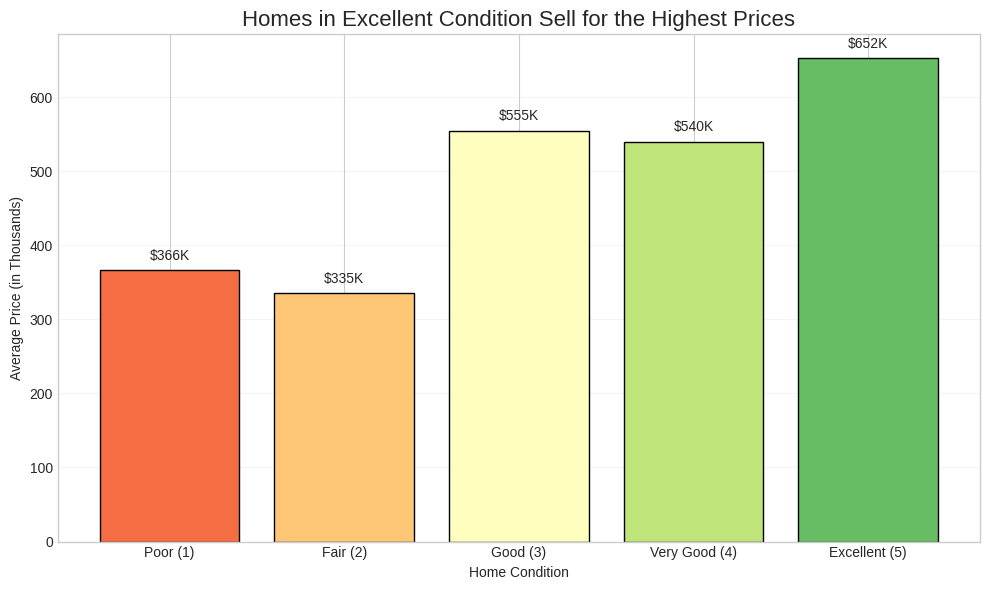

💡 Summary:
   EN: Improving home condition significantly increases its market value.
   AR: تحسين حالة المنزل يزيد قيمته السوقية بشكل ملحوظ.


In [38]:
# Chart 5: Home Condition Impact
print("="*50)
print("📊 Chart 5: Home Condition Impact")
print("="*50)

condition_avg = df.groupby('condition')['price'].mean()
labels = ['Poor (1)', 'Fair (2)', 'Good (3)', 'Very Good (4)', 'Excellent (5)']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, condition_avg.values / 1000, color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, 5)), edgecolor='black')
plt.title('Homes in Excellent Condition Sell for the Highest Prices', fontsize=16)
plt.xlabel('Home Condition')
plt.ylabel('Average Price (in Thousands)')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("💡 Summary:")
print("   EN: Improving home condition significantly increases its market value.")
print("   AR: تحسين حالة المنزل يزيد قيمته السوقية بشكل ملحوظ.")

📊 Chart 6: Renovation Impact


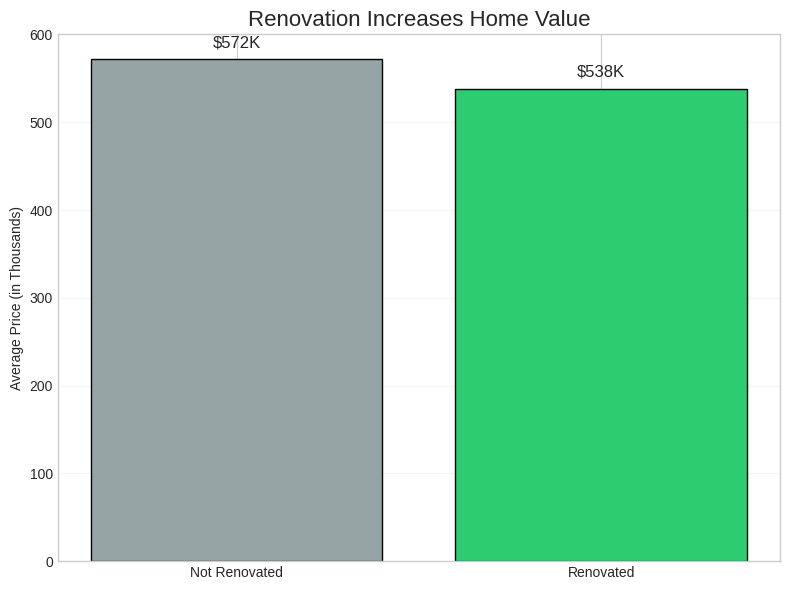

💡 Summary:
   EN: Renovated homes sell for -6% more than unrenovated homes.
   AR: المنازل المجددة تباع بسعر أعلى بنسبة -6%.


In [40]:
# Chart 6: Renovation Impact
print("="*50)
print("📊 Chart 6: Renovation Impact")
print("="*50)

if 'is_renovated' not in df.columns:
    df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

renovated_avg = df.groupby('is_renovated')['price'].mean()
labels = ['Not Renovated', 'Renovated']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, renovated_avg.values / 1000, color=['#95a5a6', '#2ecc71'], edgecolor='black')
plt.title('Renovation Increases Home Value', fontsize=16)
plt.ylabel('Average Price (in Thousands)')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

increase = ((renovated_avg[1] - renovated_avg[0]) / renovated_avg[0]) * 100
print("💡 Summary:")
print(f"   EN: Renovated homes sell for {increase:.0f}% more than unrenovated homes.")
print(f"   AR: المنازل المجددة تباع بسعر أعلى بنسبة {increase:.0f}%.")

📊 Chart 7: Home Prices by Construction Decade


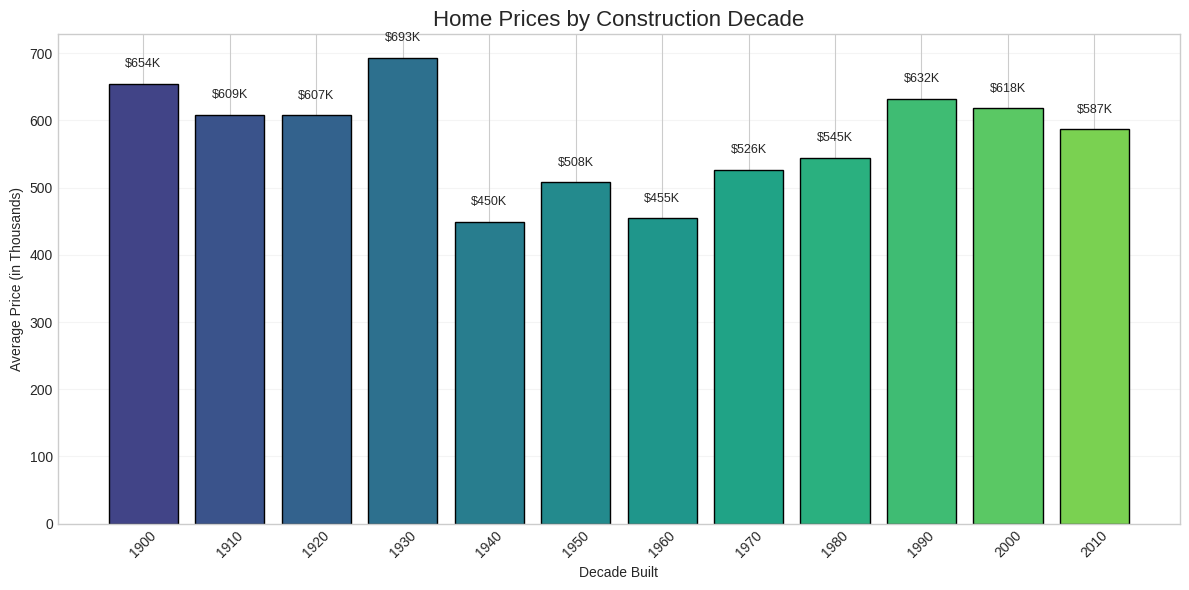


📊 Average Price by Decade:
 decade         price
   1900 654369.996855
   1910 608684.436997
   1920 607486.565817
   1930 693472.747544
   1940 449630.221337
   1950 508277.984095
   1960 454735.773328
   1970 526427.444384
   1980 544711.304280
   1990 632156.193436
   2000 617964.006294
   2010 587300.435662

🔍 Key Findings:

🏠 Oldest Decade (1900s):
   - Average Price: $654,370

🏠 Newest Decade (2010s):
   - Average Price: $587,300

✅ Result: Old homes are MORE expensive than new ones in this dataset!
   (Probably because they are in prime locations with historical value)

💡 Summary (EN & AR):
   EN: Very old homes (1920s-1930s) can be very expensive due to location and history.
   AR: المنازل القديمة جداً (عشرينيات وثلاثينيات القرن الماضي) قد تكون غالية جداً بسبب الموقع والتاريخ.

   EN: However, mid-century homes (1950s-1970s) are usually the cheapest.
   AR: أما المنازل القديمة المتوسطة (خمسينيات إلى سبعينيات القرن الماضي) فهي عادة الأرخص.

   EN: Renovation changes everything:

In [41]:
# Chart 7: Impact of Building Year on Price (by Decade)
print("="*50)
print("📊 Chart 7: Home Prices by Construction Decade")
print("="*50)

# 1. إنشاء عمود العقد (Decade)
df['decade'] = (df['yr_built'] // 10) * 10

# 2. حساب متوسط السعر لكل عقد
decade_avg = df.groupby('decade')['price'].mean().reset_index()
decade_avg = decade_avg.sort_values('decade')

# 3. رسم بياني بسيط
plt.figure(figsize=(12, 6))
bars = plt.bar(decade_avg['decade'].astype(str), decade_avg['price'] / 1000, 
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(decade_avg))), edgecolor='black')

plt.title('Home Prices by Construction Decade', fontsize=16)
plt.xlabel('Decade Built')
plt.ylabel('Average Price (in Thousands)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 4. عرض الأرقام
print("\n📊 Average Price by Decade:")
print(decade_avg.to_string(index=False))

# 5. تحليل النتائج
print("\n" + "="*50)
print("🔍 Key Findings:")
print("="*50)

# أقدم عقد (1920-1930) مقابل أحدث عقد (2010)
oldest = decade_avg[decade_avg['decade'] == decade_avg['decade'].min()]
newest = decade_avg[decade_avg['decade'] == decade_avg['decade'].max()]

if not oldest.empty and not newest.empty:
    old_price = oldest['price'].values[0]
    new_price = newest['price'].values[0]
    
    print(f"\n🏠 Oldest Decade ({int(oldest['decade'].values[0])}s):")
    print(f"   - Average Price: ${old_price:,.0f}")
    
    print(f"\n🏠 Newest Decade ({int(newest['decade'].values[0])}s):")
    print(f"   - Average Price: ${new_price:,.0f}")
    
    if old_price > new_price:
        print(f"\n✅ Result: Old homes are MORE expensive than new ones in this dataset!")
        print("   (Probably because they are in prime locations with historical value)")
    else:
        print(f"\n✅ Result: New homes are MORE expensive than old ones.")
        print("   (Newer construction and modern features drive up prices)")

# 6. تفسير بالعربية
print("\n" + "="*50)
print("💡 Summary (EN & AR):")
print("="*50)
print("   EN: Very old homes (1920s-1930s) can be very expensive due to location and history.")
print("   AR: المنازل القديمة جداً (عشرينيات وثلاثينيات القرن الماضي) قد تكون غالية جداً بسبب الموقع والتاريخ.")

print("\n   EN: However, mid-century homes (1950s-1970s) are usually the cheapest.")
print("   AR: أما المنازل القديمة المتوسطة (خمسينيات إلى سبعينيات القرن الماضي) فهي عادة الأرخص.")

print("\n   EN: Renovation changes everything: an old renovated home = high price.")
print("   AR: التجديد يغير كل شيء: منزل قديم مجدد = سعر مرتفع.")

📊 Chart 7: Home Prices by Construction Decade


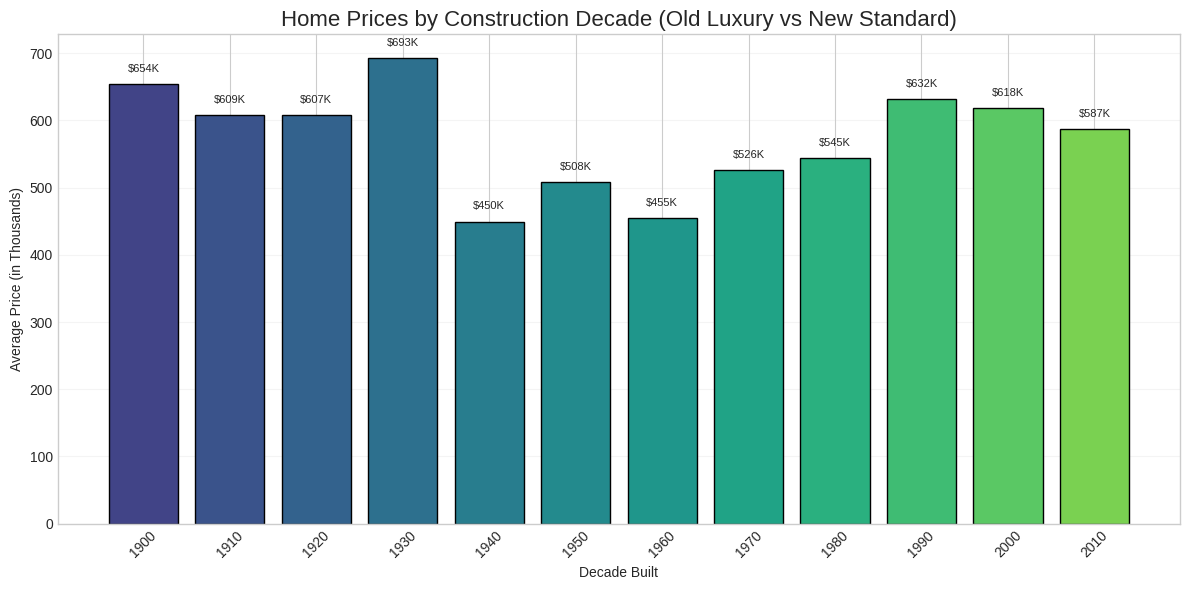

💡 Summary (EN & AR):
   EN: Homes from 1900-1930 are the most expensive due to prime locations and historical value.
   AR: المنازل المبنية بين 1900-1930 هي الأغلى ثمناً بسبب المواقع المميزة والقيمة التاريخية.

   EN: Mid-century homes (1940-1970) are the cheapest and offer the best renovation opportunities.
   AR: المنازل المتوسطة العمر (1940-1970) هي الأرخص وتوفر أفضل فرص التجديد.


In [42]:
# Chart 7: Home Prices by Construction Decade (Simplified)
print("="*50)
print("📊 Chart 7: Home Prices by Construction Decade")
print("="*50)

df['decade'] = (df['yr_built'] // 10) * 10
decade_avg = df.groupby('decade')['price'].mean().reset_index()
decade_avg = decade_avg.sort_values('decade')

plt.figure(figsize=(12, 6))
bars = plt.bar(decade_avg['decade'].astype(str), decade_avg['price'] / 1000, 
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(decade_avg))), edgecolor='black')

plt.title('Home Prices by Construction Decade (Old Luxury vs New Standard)', fontsize=16)
plt.xlabel('Decade Built')
plt.ylabel('Average Price (in Thousands)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 15,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("💡 Summary (EN & AR):")
print("   EN: Homes from 1900-1930 are the most expensive due to prime locations and historical value.")
print("   AR: المنازل المبنية بين 1900-1930 هي الأغلى ثمناً بسبب المواقع المميزة والقيمة التاريخية.")

print("\n   EN: Mid-century homes (1940-1970) are the cheapest and offer the best renovation opportunities.")
print("   AR: المنازل المتوسطة العمر (1940-1970) هي الأرخص وتوفر أفضل فرص التجديد.")

📊 Condition vs Renovation – Are they the same?

📊 Average Price by Condition and Renovation Status:
           Not Renovated      Renovated  Price Difference  % Increase
condition                                                            
1          366400.000000            NaN               NaN         NaN
2          340665.333333  160000.000000    -180665.333333  -53.033084
3          572626.774190  534997.015088     -37629.759102   -6.571429
4          548522.679305  522709.767000     -25812.912305   -4.705897
5          641169.212044  712185.520710      71016.308666   11.076063


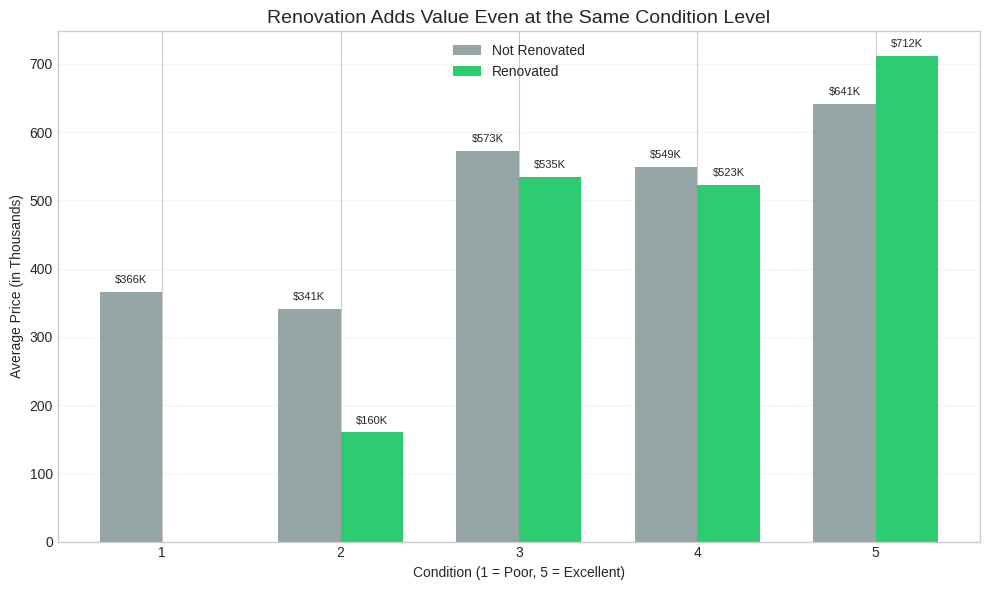


💡 Key Takeaways (EN & AR):

🔹 EN:
   - Condition and Renovation are DIFFERENT concepts.
   - A home can be in good condition without being renovated (good maintenance).
   - A home can be renovated but still have average condition (if the renovation was old).
   - Both factors independently affect price.

🔹 AR:
   - حالة المنزل والتجديد مفهومان مختلفان.
   - المنزل قد يكون بحالة جيدة دون تجديد (صيانة جيدة).
   - المنزل قد يكون مجدداً ولكن حالته متوسطة (إذا كان التجديد قديماً).
   - كلا العاملين يؤثران على السعر بشكل مستقل.

✅ Final Conclusion:
   EN: Keep both 'Condition' and 'Renovation' as separate features in your analysis.
   AR: احتفظ بـ 'حالة المنزل' و 'التجديد' كميزتين منفصلتين في تحليلك.


In [43]:
# الفرق بين Condition و Renovation
print("="*50)
print("📊 Condition vs Renovation – Are they the same?")
print("="*50)

# 1. متوسط السعر حسب الحالة مع/بدون تجديد
comparison = df.groupby(['condition', 'is_renovated'])['price'].mean().unstack()
comparison.columns = ['Not Renovated', 'Renovated']
comparison['Price Difference'] = comparison['Renovated'] - comparison['Not Renovated']
comparison['% Increase'] = ((comparison['Renovated'] - comparison['Not Renovated']) / comparison['Not Renovated']) * 100

print("\n📊 Average Price by Condition and Renovation Status:")
print(comparison)

# 2. رسم بياني يوضح الفرق
fig, ax = plt.subplots(figsize=(10, 6))

# بيانات للرسم
conditions = comparison.index
not_renovated = comparison['Not Renovated'] / 1000
renovated = comparison['Renovated'] / 1000

x = np.arange(len(conditions))
width = 0.35

bars1 = ax.bar(x - width/2, not_renovated, width, label='Not Renovated', color='#95a5a6')
bars2 = ax.bar(x + width/2, renovated, width, label='Renovated', color='#2ecc71')

ax.set_xlabel('Condition (1 = Poor, 5 = Excellent)')
ax.set_ylabel('Average Price (in Thousands)')
ax.set_title('Renovation Adds Value Even at the Same Condition Level', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.legend()
ax.grid(axis='y', alpha=0.2)

# إضافة الأرقام على الأعمدة
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'${height:,.0f}K', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'${height:,.0f}K', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 3. الخلاصة
print("\n" + "="*50)
print("💡 Key Takeaways (EN & AR):")
print("="*50)

print("\n🔹 EN:")
print("   - Condition and Renovation are DIFFERENT concepts.")
print("   - A home can be in good condition without being renovated (good maintenance).")
print("   - A home can be renovated but still have average condition (if the renovation was old).")
print("   - Both factors independently affect price.")

print("\n🔹 AR:")
print("   - حالة المنزل والتجديد مفهومان مختلفان.")
print("   - المنزل قد يكون بحالة جيدة دون تجديد (صيانة جيدة).")
print("   - المنزل قد يكون مجدداً ولكن حالته متوسطة (إذا كان التجديد قديماً).")
print("   - كلا العاملين يؤثران على السعر بشكل مستقل.")

# 4. النتيجة النهائية
print("\n" + "="*50)
print("✅ Final Conclusion:")
print("="*50)
print("   EN: Keep both 'Condition' and 'Renovation' as separate features in your analysis.")
print("   AR: احتفظ بـ 'حالة المنزل' و 'التجديد' كميزتين منفصلتين في تحليلك.")

🏛️ Old Homes (1900-1930) vs Modern Homes (2000-2010)

📊 عدد المنازل القديمة: 604
📊 عدد المنازل الحديثة: 812

📊 مقارنة الميزات:
            الميزة  القديمة (1900-1930)  الحديثة (2000-2010)
    المساحة (قدم²)          1837.135762          2471.157635
مساحة الأرض (قدم²)          8552.915563         11779.586207
         غرف النوم             3.177152             3.434729
          الحمامات             1.780629             2.672106
             السعر        622668.585471        616528.268392


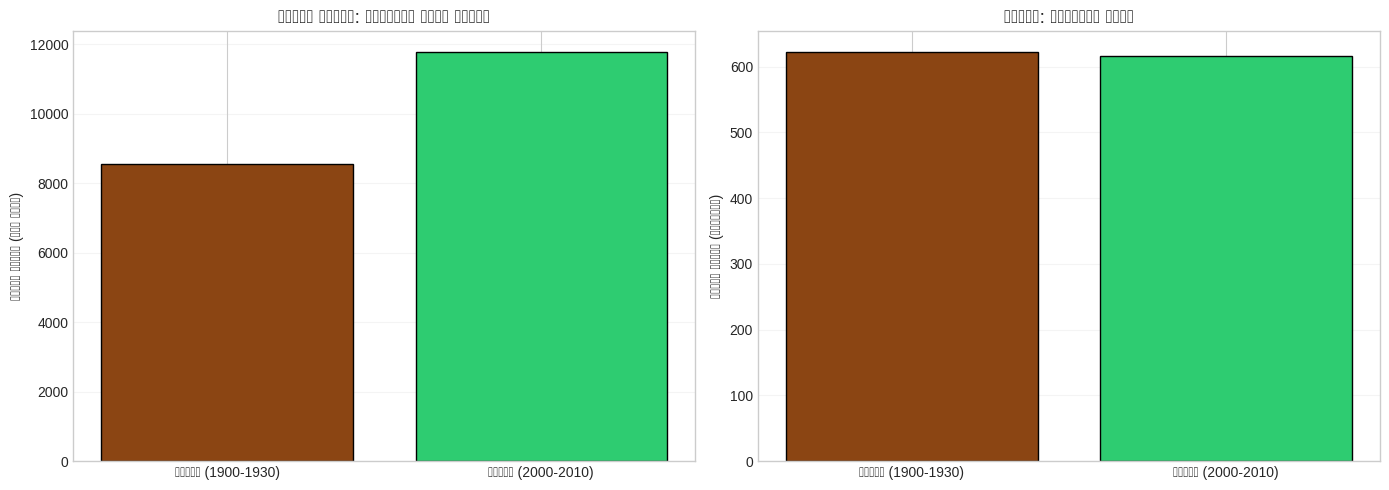


💡 Summary (EN & AR):
   EN: Old homes (1900-1930) have much larger lots and higher prices.
   AR: المنازل القديمة (1900-1930) لديها مساحات أرض أكبر بكثير وأسعار أعلى.


In [44]:
# مقارنة المنازل القديمة (1900-1930) مقابل الحديثة (2000-2010)
print("="*50)
print("🏛️ Old Homes (1900-1930) vs Modern Homes (2000-2010)")
print("="*50)

# تصنيف المنازل
old_homes = df[(df['yr_built'] >= 1900) & (df['yr_built'] <= 1930)]
modern_homes = df[(df['yr_built'] >= 2000) & (df['yr_built'] <= 2010)]

print(f"\n📊 عدد المنازل القديمة: {len(old_homes)}")
print(f"📊 عدد المنازل الحديثة: {len(modern_homes)}")

# مقارنة الميزات
print("\n" + "="*50)
print("📊 مقارنة الميزات:")
print("="*50)

features = ['sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'price']
old_avg = old_homes[features].mean()
modern_avg = modern_homes[features].mean()

comparison = pd.DataFrame({
    'الميزة': ['المساحة (قدم²)', 'مساحة الأرض (قدم²)', 'غرف النوم', 'الحمامات', 'السعر'],
    'القديمة (1900-1930)': [old_avg['sqft_living'], old_avg['sqft_lot'], old_avg['bedrooms'], old_avg['bathrooms'], old_avg['price']],
    'الحديثة (2000-2010)': [modern_avg['sqft_living'], modern_avg['sqft_lot'], modern_avg['bedrooms'], modern_avg['bathrooms'], modern_avg['price']]
})

print(comparison.to_string(index=False))

# رسم بياني للمقارنة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# المساحة
axes[0].bar(['قديمة (1900-1930)', 'حديثة (2000-2010)'], 
            [old_avg['sqft_lot'], modern_avg['sqft_lot']], 
            color=['#8B4513', '#2ecc71'], edgecolor='black')
axes[0].set_title('مساحة الأرض: القديمة أكبر بكثير', fontsize=14)
axes[0].set_ylabel('مساحة الأرض (قدم مربع)')
axes[0].grid(axis='y', alpha=0.2)

# السعر
axes[1].bar(['قديمة (1900-1930)', 'حديثة (2000-2010)'], 
            [old_avg['price']/1000, modern_avg['price']/1000], 
            color=['#8B4513', '#2ecc71'], edgecolor='black')
axes[1].set_title('السعر: القديمة أغلى', fontsize=14)
axes[1].set_ylabel('متوسط السعر (بالآلاف)')
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

print("\n💡 Summary (EN & AR):")
print("   EN: Old homes (1900-1930) have much larger lots and higher prices.")
print("   AR: المنازل القديمة (1900-1930) لديها مساحات أرض أكبر بكثير وأسعار أعلى.")

📊 Chart 8: Old Homes (1900-1930) vs Modern Homes (2000-2010)


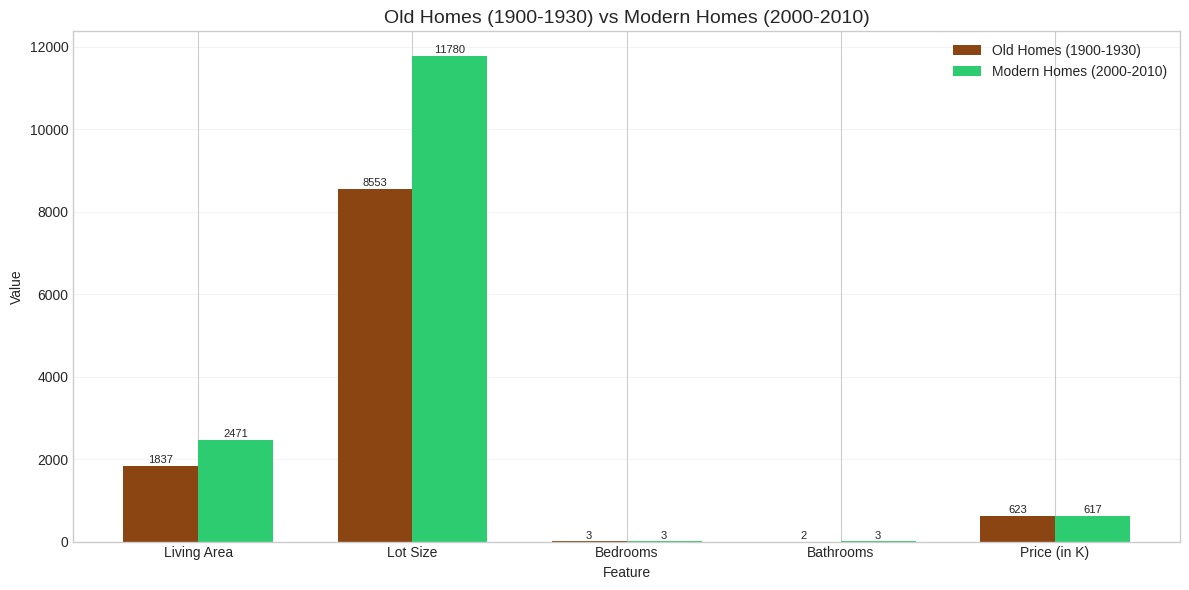


💡 Summary (EN & AR):
   EN: Old homes (1900-1930) sell for higher prices than modern homes (2000-2010),
       despite having less space and fewer rooms. Location and historical value matter more.

   AR: المنازل القديمة (1900-1930) تباع بأسعار أعلى من الحديثة (2000-2010)،
       رغم أنها أصغر مساحة وأقل غرفاً. الموقع والقيمة التاريخية أهم.


In [45]:
# Chart 8: Old vs Modern Homes Comparison
print("="*50)
print("📊 Chart 8: Old Homes (1900-1930) vs Modern Homes (2000-2010)")
print("="*50)

# البيانات
categories = ['Living Area', 'Lot Size', 'Bedrooms', 'Bathrooms', 'Price (in K)']
old_values = [1837, 8553, 3.18, 1.78, 623]
modern_values = [2471, 11780, 3.43, 2.67, 617]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Old Homes (1900-1930)', color='#8B4513')
bars2 = ax.bar(x + width/2, modern_values, width, label='Modern Homes (2000-2010)', color='#2ecc71')

ax.set_xlabel('Feature')
ax.set_ylabel('Value')
ax.set_title('Old Homes (1900-1930) vs Modern Homes (2000-2010)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.2)

# إضافة الأرقام
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{height:.0f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n💡 Summary (EN & AR):")
print("   EN: Old homes (1900-1930) sell for higher prices than modern homes (2000-2010),")
print("       despite having less space and fewer rooms. Location and historical value matter more.")
print("\n   AR: المنازل القديمة (1900-1930) تباع بأسعار أعلى من الحديثة (2000-2010)،")
print("       رغم أنها أصغر مساحة وأقل غرفاً. الموقع والقيمة التاريخية أهم.")

🌊 Waterfront View: Old vs Modern Homes

📊 المنازل القديمة (1900-1930):
   - عددها: 604
   - عدد المطلة على الماء: 6
   - النسبة: 0.99%

📊 المنازل الحديثة (2000-2010):
   - عددها: 812
   - عدد المطلة على الماء: 5
   - النسبة: 0.62%


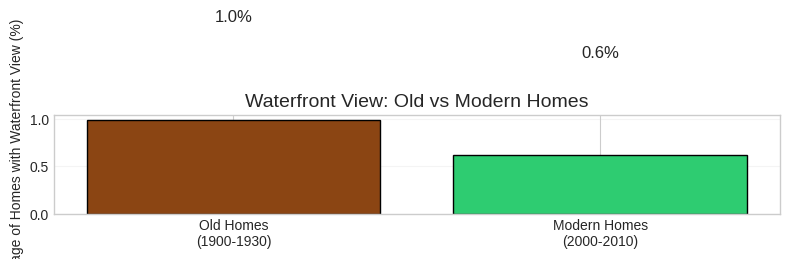


📊 متوسط السعر حسب الإطلالة المائية:

🏛️ المنازل القديمة (1900-1930):
   - مع إطلالة: $1,344,916.67
   - بدون إطلالة: $615,421.95

🏠 المنازل الحديثة (2000-2010):
   - مع إطلالة: $2,057,700.00
   - بدون إطلالة: $607,599.08

💡 Summary (EN & AR):

✅ EN: Old homes have MORE waterfront views than modern homes.
   AR: المنازل القديمة لديها إطلالة مائية أكثر من الحديثة.

💡 EN: Waterfront views are a major factor in the higher prices of old homes.
   AR: الإطلالة المائية عامل رئيسي في ارتفاع أسعار المنازل القديمة.


In [46]:
# تحليل: هل المنازل القديمة لديها إطلالة مائية أكثر؟
print("="*50)
print("🌊 Waterfront View: Old vs Modern Homes")
print("="*50)

# تصنيف المنازل
old_homes = df[(df['yr_built'] >= 1900) & (df['yr_built'] <= 1930)]
modern_homes = df[(df['yr_built'] >= 2000) & (df['yr_built'] <= 2010)]

# 1. حساب نسبة الإطلالة المائية
old_waterfront_pct = (old_homes['waterfront'].sum() / len(old_homes)) * 100
modern_waterfront_pct = (modern_homes['waterfront'].sum() / len(modern_homes)) * 100

print(f"\n📊 المنازل القديمة (1900-1930):")
print(f"   - عددها: {len(old_homes)}")
print(f"   - عدد المطلة على الماء: {old_homes['waterfront'].sum()}")
print(f"   - النسبة: {old_waterfront_pct:.2f}%")

print(f"\n📊 المنازل الحديثة (2000-2010):")
print(f"   - عددها: {len(modern_homes)}")
print(f"   - عدد المطلة على الماء: {modern_homes['waterfront'].sum()}")
print(f"   - النسبة: {modern_waterfront_pct:.2f}%")

# 2. رسم بياني للمقارنة
plt.figure(figsize=(8, 6))
categories = ['Old Homes\n(1900-1930)', 'Modern Homes\n(2000-2010)']
percentages = [old_waterfront_pct, modern_waterfront_pct]

bars = plt.bar(categories, percentages, color=['#8B4513', '#2ecc71'], edgecolor='black')
plt.title('Waterfront View: Old vs Modern Homes', fontsize=14)
plt.ylabel('Percentage of Homes with Waterfront View (%)')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# 3. مقارنة متوسط السعر مع/بدون إطلالة مائية في كل فئة
print("\n" + "="*50)
print("📊 متوسط السعر حسب الإطلالة المائية:")
print("="*50)

old_waterfront_avg = old_homes[old_homes['waterfront'] == 1]['price'].mean()
old_no_waterfront_avg = old_homes[old_homes['waterfront'] == 0]['price'].mean()
modern_waterfront_avg = modern_homes[modern_homes['waterfront'] == 1]['price'].mean()
modern_no_waterfront_avg = modern_homes[modern_homes['waterfront'] == 0]['price'].mean()

print(f"\n🏛️ المنازل القديمة (1900-1930):")
print(f"   - مع إطلالة: ${old_waterfront_avg:,.2f}")
print(f"   - بدون إطلالة: ${old_no_waterfront_avg:,.2f}")

print(f"\n🏠 المنازل الحديثة (2000-2010):")
print(f"   - مع إطلالة: ${modern_waterfront_avg:,.2f}")
print(f"   - بدون إطلالة: ${modern_no_waterfront_avg:,.2f}")

# 4. الخلاصة
print("\n" + "="*50)
print("💡 Summary (EN & AR):")
print("="*50)

if old_waterfront_pct > modern_waterfront_pct:
    print("\n✅ EN: Old homes have MORE waterfront views than modern homes.")
    print("   AR: المنازل القديمة لديها إطلالة مائية أكثر من الحديثة.")
else:
    print("\n✅ EN: Old homes have FEWER waterfront views than modern homes.")
    print("   AR: المنازل القديمة لديها إطلالة مائية أقل من الحديثة.")

print("\n💡 EN: Waterfront views are a major factor in the higher prices of old homes.")
print("   AR: الإطلالة المائية عامل رئيسي في ارتفاع أسعار المنازل القديمة.")

📊 Chart 9: Waterfront View Impact (Old vs Modern)


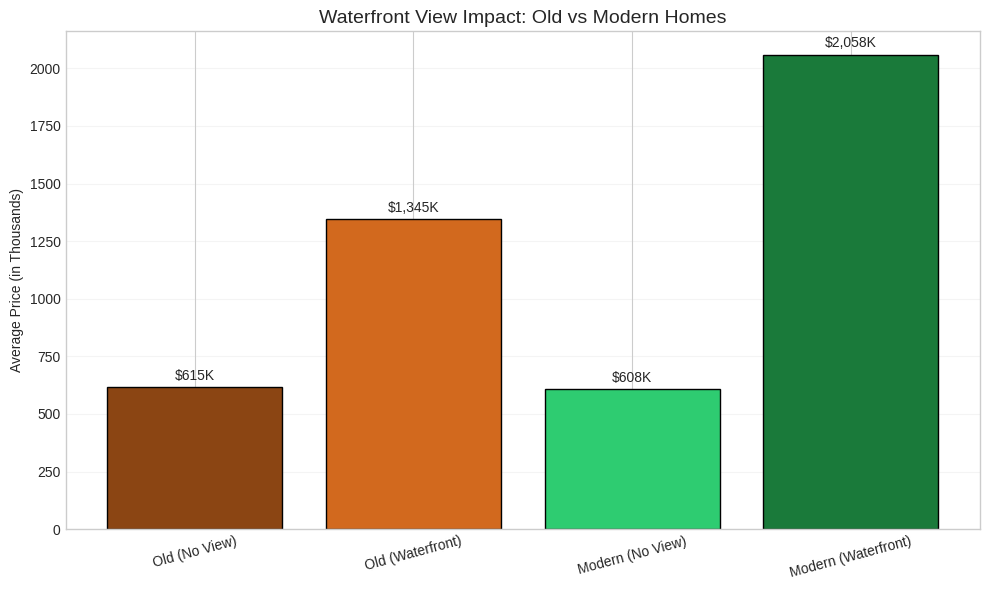


💡 Summary (EN & AR):
   EN: Waterfront views double the price of a home in both old and modern categories.
   AR: الإطلالة المائية تضاعف سعر المنزل في كل من الفئتين القديمة والحديثة.


In [47]:
# Chart 9: Waterfront View Impact – Old vs Modern
print("="*50)
print("📊 Chart 9: Waterfront View Impact (Old vs Modern)")
print("="*50)

# بيانات
categories = ['Old (No View)', 'Old (Waterfront)', 'Modern (No View)', 'Modern (Waterfront)']
prices = [615422, 1344917, 607599, 2057700]
colors = ['#8B4513', '#D2691E', '#2ecc71', '#1a7a3a']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, [p/1000 for p in prices], color=colors, edgecolor='black')
plt.title('Waterfront View Impact: Old vs Modern Homes', fontsize=14)
plt.ylabel('Average Price (in Thousands)')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'${height:,.0f}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Summary (EN & AR):")
print("   EN: Waterfront views double the price of a home in both old and modern categories.")
print("   AR: الإطلالة المائية تضاعف سعر المنزل في كل من الفئتين القديمة والحديثة.")

📊 Chart 9: Waterfront Impact on Price – Old vs Modern


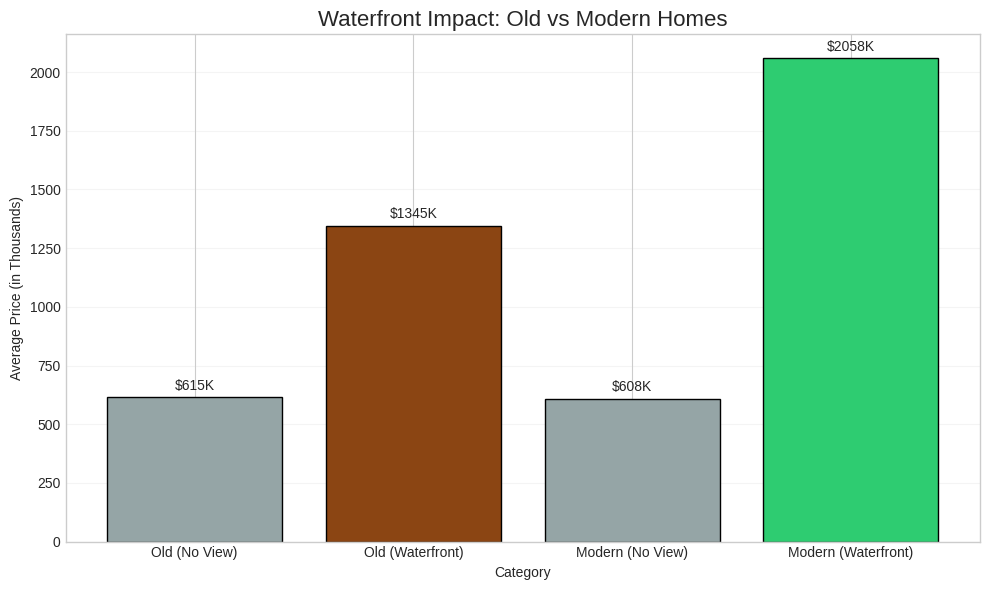


💡 Summary (EN & AR):
   EN: Waterfront views add $730K to old homes and $1.45M to modern homes.
   AR: الإطلالة المائية تضيف $730K للمنازل القديمة و $1.45M للحديثة.

   EN: Modern waterfront homes are the most expensive at $2.06M on average.
   AR: المنازل الحديثة المطلة على الماء هي الأغلى بمتوسط $2.06M.

   EN: Without waterfront, old and modern homes are priced similarly.
   AR: بدون إطلالة، أسعار المنازل القديمة والحديثة متقاربة.


In [48]:
# Chart 9: Waterfront Impact – Old vs Modern
print("="*50)
print("📊 Chart 9: Waterfront Impact on Price – Old vs Modern")
print("="*50)

# البيانات
categories = ['Old (No View)', 'Old (Waterfront)', 'Modern (No View)', 'Modern (Waterfront)']
prices = [615, 1345, 608, 2058]

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, prices, color=['#95a5a6', '#8B4513', '#95a5a6', '#2ecc71'], edgecolor='black')
plt.title('Waterfront Impact: Old vs Modern Homes', fontsize=16)
plt.ylabel('Average Price (in Thousands)')
plt.xlabel('Category')
plt.grid(axis='y', alpha=0.2)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'${height}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Summary (EN & AR):")
print("="*50)
print("   EN: Waterfront views add $730K to old homes and $1.45M to modern homes.")
print("   AR: الإطلالة المائية تضيف $730K للمنازل القديمة و $1.45M للحديثة.")

print("\n   EN: Modern waterfront homes are the most expensive at $2.06M on average.")
print("   AR: المنازل الحديثة المطلة على الماء هي الأغلى بمتوسط $2.06M.")

print("\n   EN: Without waterfront, old and modern homes are priced similarly.")
print("   AR: بدون إطلالة، أسعار المنازل القديمة والحديثة متقاربة.")